In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn import (datasets, metrics)
from matplotlib.colors import ListedColormap
import time

1.1. Load a dataset partially

In [2]:
iris = datasets.load_iris()
iris.data = iris.data[:,0:2]
iris.feature_names = iris.feature_names[0:2]
iris.color = np.array([(1, 0, 0), (0, 1, 0), (0, 0, 1)])
# 1.2. Load the dataset as tensors
dev_name = 'cuda' if torch.cuda.is_available() else 'cpu' # Try 'cpu'
x = torch.tensor(iris.data, device=dev_name).float()
y = torch.tensor(iris.target, device=dev_name).long()

2. Define a model<br>
- Try the different number of hidden layers<br>
- Try less or more layers with different transfer functions

In [3]:
input_size, output_size = len(iris.feature_names), len(iris.target_names)
model = nn.Sequential(
    nn.Linear(input_size, 4),
    nn.ReLU(),
    nn.Linear(4, output_size),
).to(dev_name)

3. Train the model

In [4]:
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01) # Try other optimizers
epoch_max = 10000
loss_list = []
start = time.time()
for i in range(epoch_max):
    # Train one iteration
    optimizer.zero_grad()
    output = model(x)
    loss = loss_func(output, y)
    loss.backward()
    optimizer.step()
    # Record the loss
    loss = loss.detach().numpy()
    loss_list.append(loss / len(x))
elapse = time.time() - start

4.1. Visualize the training loss curve

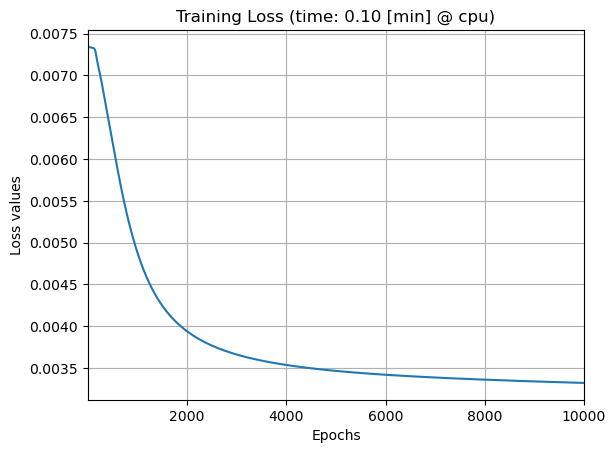

In [5]:
plt.title(f'Training Loss (time: {elapse/60:.2f} [min] @ {dev_name})')
plt.plot(range(1, epoch_max + 1), loss_list)
plt.xlabel('Epochs')
plt.ylabel('Loss values')
plt.xlim((1, epoch_max))
plt.grid()
plt.show()

4.2. Visualize training results (decision boundaries)

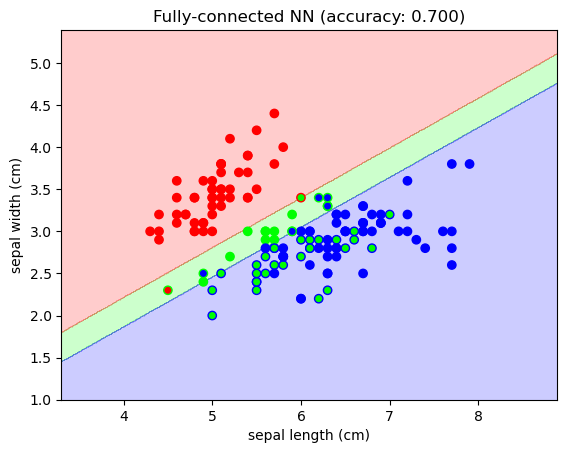

In [6]:
x_min, x_max = iris.data[:, 0].min() - 1, iris.data[:, 0].max() + 1
y_min, y_max = iris.data[:, 1].min() - 1, iris.data[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
xy = np.vstack((xx.flatten(), yy.flatten())).T
xy_tensor = torch.from_numpy(xy).float().to(dev_name)
zz = torch.argmax(model(xy_tensor), dim=1).cpu().detach().numpy()
plt.contourf(xx, yy, zz.reshape(xx.shape), cmap=ListedColormap(iris.color), alpha=0.2)
# 4.3. Visualize data with their classification
predict = torch.argmax(model(x), dim=1).cpu().detach().numpy()
accuracy = metrics.balanced_accuracy_score(iris.target, predict)
plt.title(f'Fully-connected NN (accuracy: {accuracy:.3f})')
plt.scatter(iris.data[:,0], iris.data[:,1], c=iris.color[iris.target], edgecolors=iris.color[predict])
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.show()